# MODELO DE REGRESION LINEAL SIMPLE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep='\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# CORRELACIONES

<Axes: >

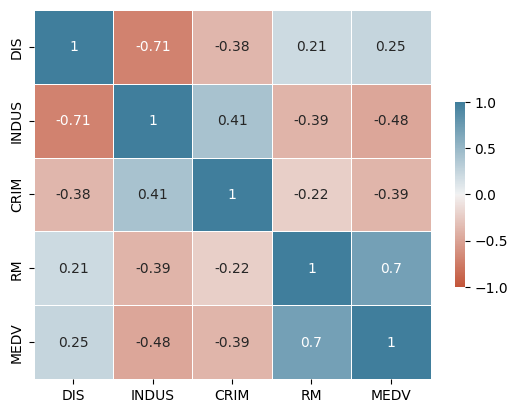

In [3]:
cols = ['DIS','INDUS','CRIM', 'RM', 'MEDV']
sns.heatmap(
    data=df[cols].corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

<Axes: xlabel='RM', ylabel='MEDV'>

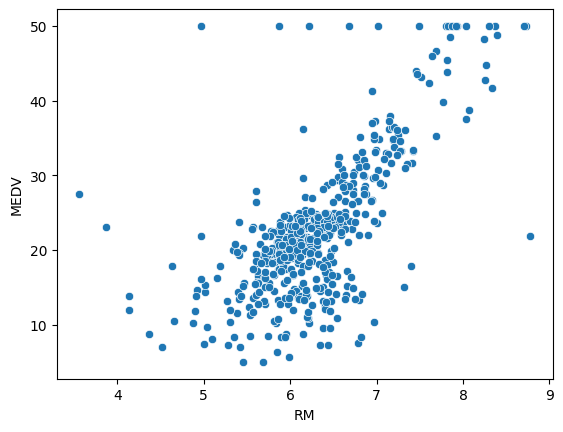

In [4]:
sns.scatterplot(data=df,x=df['RM'],y=df['MEDV'])

## 🧮 1. Regresión Lineal Simple

Es el caso más básico donde se relaciona **una sola variable independiente** `X` con la variable dependiente `Y`.

### 📐 Ecuación:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

- \( Y \): variable dependiente  
- \( X \): variable independiente  
- \( \beta_0 \): intercepto o término independiente  
- \( \beta_1 \): pendiente o coeficiente de regresión  
- \( \varepsilon \): término de error (ruido)

---

# CREANDO DEL MODELO DE REGRESIÓN LIENAL CON SKLEARN

## PASO 1 - DEFINIMOS VARIABLE X Y Y

X = RM(PROMEDIO DE HABITACIONES EN EL DEPARTAMENTO)
Y = MEDV(VALOR PROMEDIO DEL DEPARTAMENTO)

In [5]:
X = df['RM'].values.reshape(-1,1)
y = df['MEDV'].values.reshape(-1,1)

## PASO 2 IMPORTAMOS LIBRERIAS

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

## PASO 3 ESTANDARIZAMOS LOS VALORES

In [7]:
sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y)

## PASO 4 - CREAMOS EL MODELO

In [ ]:
slr = LinearRegression()
slr.fit(X_std,y_std)
slr.predict(X_std)

# GRAFICAMOS LOS RESULTADOS

Text(0.5, 0, 'RM')

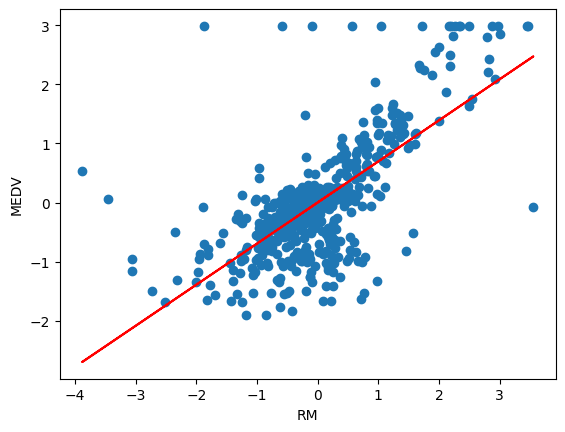

In [9]:
plt.scatter(X_std,y_std)
plt.plot(X_std,slr.predict(X_std),color='red')
plt.ylabel('MEDV')
plt.xlabel('RM')

# PROBAMOS PREDICCIONES

In [11]:
num_hab = 7
num_hab_std = sc_x.transform(np.array([num_hab]).reshape(-1,1))
print(f" EL PRECIO PARA UN DPTO CON {num_hab}  ES DE : {sc_y.inverse_transform(slr.predict(num_hab_std))}")

 EL PRECIO PARA UN DPTO CON 7  ES DE : [[29.04414209]]


# ENTRENAMOS NUESTRO MODELO DIVIENDO EL DATASET EN TRAIN Y TEST

In [12]:
from sklearn.model_selection import train_test_split

data = df.copy()
data.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6


In [13]:
X = data['RM'].values.reshape(-1,1)
y = data['MEDV'].values.reshape(-1,1)

# DIVIDIMOS EL DATASET EN 70% PARA ENTRENAMIENTO Y 30% PARA PRUEBAS

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

In [15]:
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)

In [ ]:
slr = LinearRegression()
slr.fit(X_std,y_std)
slr.predict(X_std)

In [22]:
y_pred = slr.predict(X_test)
y_pred.shape

(152, 1)

# EVALUAMOS EL MODELO CON METRICAS MSE Y R2

MSE nos dice cuánto se equivoca el modelo.(0 es lo ideal)

R² nos dice qué tanto del comportamiento del dato ha logrado explicar el modelo.(1 es lo ideal)

In [23]:
import sklearn.metrics as metrics

In [24]:
#error cuadratico medio
mse = metrics.mean_squared_error(y_test,y_pred)
#R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.517
El coeficiente de determinación(R2) es de 0.483


# PROBAMOS PREDICCIONES

In [26]:
num_habitaciones = 5
num_habitaciones_std = sc_x.transform(np.array([num_habitaciones]).reshape(-1,1))
print("EL PRECIO DE UN DPTO CON 5 HABITACIONES ES DE :",sc_y.inverse_transform(slr.predict(num_habitaciones_std))*1000)

EL PRECIO DE UN DPTO CON 5 HABITACIONES ES DE : [[10484.11379431]]


# GUARDAMOS EL MODELO

In [27]:
import joblib
joblib.dump(slr,'housing-ml.pkl')

['housing-ml.pkl']

# GUARDAMOS LOS SCALERS

In [28]:
joblib.dump(sc_x,'scaler_x.pkl')
joblib.dump(sc_y,'scaler_y.pkl')

['scaler_y.pkl']